In [ ]:
import os
import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

IMG_SIZE = (96, 96)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 8
IMAGES_PER_CLASS = 500

In [ ]:
print("Loading dataset from Kaggle...")

DATASET_PATH = kagglehub.dataset_download(
    "emmarex/plantdisease"
)

DATASET_DIR = os.path.join(
    DATASET_PATH,
    "PlantVillage"
)

print("Dataset loaded.")

Loading dataset from Kaggle...
Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset loaded.


In [ ]:
all_classes = sorted([
    folder for folder in os.listdir(DATASET_DIR)
    if os.path.isdir(
        os.path.join(DATASET_DIR, folder)
    )
])

tomato_classes = [
    folder for folder in all_classes
    if folder.startswith("Tomato")
]

print("\nTomato classes:")
for i, name in enumerate(tomato_classes):
    print(i, ":", name)


Tomato classes:
0 : Tomato_Bacterial_spot
1 : Tomato_Early_blight
2 : Tomato_Late_blight
3 : Tomato_Leaf_Mold
4 : Tomato_Septoria_leaf_spot
5 : Tomato_Spider_mites_Two_spotted_spider_mite
6 : Tomato__Target_Spot
7 : Tomato__Tomato_YellowLeaf__Curl_Virus
8 : Tomato__Tomato_mosaic_virus
9 : Tomato_healthy


In [ ]:
X = []
y = []

print("\nLoading images...")

for class_index, class_name in enumerate(tomato_classes):

    class_path = os.path.join(
        DATASET_DIR,
        class_name
    )

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png")
        )
    ]

    np.random.seed(SEED)
    np.random.shuffle(image_files)

    image_files = image_files[:IMAGES_PER_CLASS]

    print(
        class_name,
        "->",
        len(image_files),
        "images"
    )

    for file in image_files:

        image_path = os.path.join(
            class_path,
            file
        )

        image = tf.keras.utils.load_img(
            image_path,
            target_size=IMG_SIZE
        )

        image = tf.keras.utils.img_to_array(
            image
        )

        X.append(image)
        y.append(class_index)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("\nTotal images:", len(X))
X = X / 255.0


Loading images...
Tomato_Bacterial_spot -> 500 images
Tomato_Early_blight -> 500 images
Tomato_Late_blight -> 500 images
Tomato_Leaf_Mold -> 500 images
Tomato_Septoria_leaf_spot -> 500 images
Tomato_Spider_mites_Two_spotted_spider_mite -> 500 images
Tomato__Target_Spot -> 500 images
Tomato__Tomato_YellowLeaf__Curl_Virus -> 500 images
Tomato__Tomato_mosaic_virus -> 373 images
Tomato_healthy -> 500 images

Total images: 4873


In [ ]:
rng = np.random.default_rng(SEED)
indices = rng.permutation(len(X))

X = X[indices]
y = y[indices]

total = len(X)

train_end = int(total * 0.70)
val_end = int(total * 0.85)

X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

print("\nDataset Split:")
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))


Dataset Split:
Training: 3411
Validation: 731
Testing: 731


In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .shuffle(1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

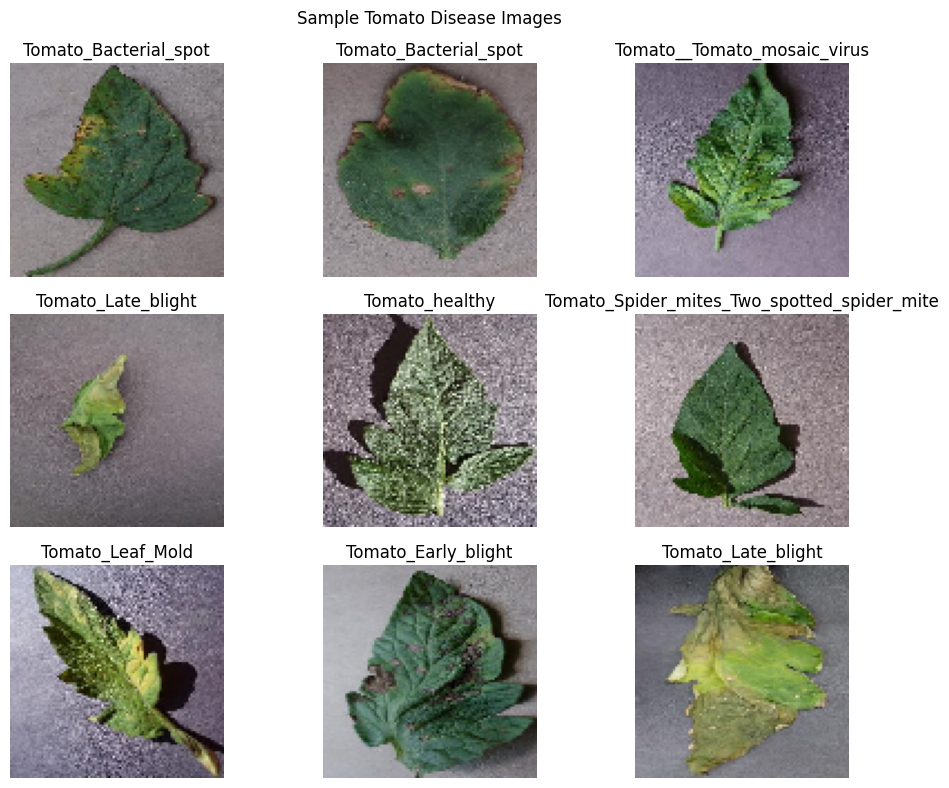

In [ ]:
plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(
            tomato_classes[labels[i].numpy()]
        )
        plt.axis("off")

plt.suptitle("Sample Tomato Disease Images")
plt.tight_layout()

In [ ]:
# ============================================
# Data Augmentation
# ============================================

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
# ============================================
# CNN Model
# ============================================

model = models.Sequential([
    layers.Input(
        shape=(96, 96, 3)
    ),

    augmentation,

    layers.Conv2D(
        16,
        3,
        activation="relu"
    ),
    layers.MaxPooling2D(),

    layers.Conv2D(
        32,
        3,
        activation="relu"
    ),
    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        activation="relu"
    ),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),
    layers.Dropout(0.3),

    layers.Dense(
        len(tomato_classes),
        activation="softmax"
    )
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 94, 94, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433,898 (1.66 MB)

 Trainable params: 433,898 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/8
107/107 ━━━━━━━━━━━━━━━━━━━━ 46s 380ms/step - accuracy: 0.2134 - loss: 2.1218 - val_accuracy: 0.3557 - val_loss: 1.6856
Epoch 2/8
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 451ms/step - accuracy: 0.3931 - loss: 1.7052 - val_accuracy: 0.4569 - val_loss: 1.6012
Epoch 3/8
107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 337ms/step - accuracy: 0.4937 - loss: 1.4803 - val_accuracy: 0.5267 - val_loss: 1.2714
Epoch 4/8
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 335ms/step - accuracy: 0.5388 - loss: 1.3124 - val_accuracy: 0.4802 - val_loss: 1.6368
Epoch 5/8
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 336ms/step - accuracy: 0.5975 - loss: 1.1908 - val_accuracy: 0.6115 - val_loss: 1.0840
Epoch 6/8
107/107 ━━━━━━━━━━━━━━━━━━━━ 35s 328ms/step - accuracy: 0.6415 - loss: 1.0232 - val_accuracy: 0.7045 - val_loss: 0.8626
Epoch 7/8
107/107 ━━━━━━━━━━━━━━━━━━━━ 42s 342ms/step - accuracy: 0.6687 - loss: 0.9448 - val_accuracy: 0.6156 - val_loss: 1.1769
Epoch 8/8
107/107 ━━━━━━━━━━━━━━━━━━━━ 43s 361ms/step - accuracy: 0.6863 - loss: 0.8881 - 

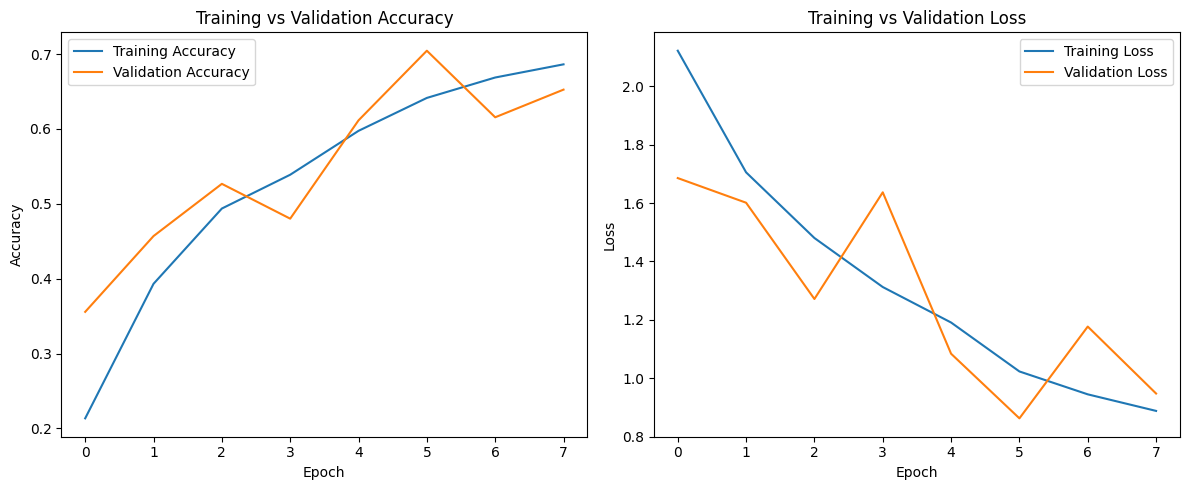

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\n================================")
print("MODEL PERFORMANCE")
print("================================")

print(
    "Test Accuracy:",
    round(test_accuracy * 100, 2),
    "%"
)
print(
    "Test Loss:",
    round(test_loss, 4)
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.6320 - loss: 1.0442

MODEL PERFORMANCE
Test Accuracy: 63.2 %
Test Loss: 1.0442


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        np.argmax(
            predictions,
            axis=1
        )
    )

print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=tomato_classes,
        zero_division=0
    )
)


Classification Report:

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.96      0.28      0.43        80
                        Tomato_Early_blight       0.59      0.48      0.53        73
                         Tomato_Late_blight       0.78      0.57      0.66        70
                           Tomato_Leaf_Mold       0.84      0.54      0.66        85
                  Tomato_Septoria_leaf_spot       0.58      0.57      0.58        77
Tomato_Spider_mites_Two_spotted_spider_mite       0.46      0.49      0.48        71
                        Tomato__Target_Spot       0.43      0.75      0.54        73
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.84      0.77      0.81        70
                Tomato__Tomato_mosaic_virus       0.58      1.00      0.74        52
                             Tomato_healthy       0.72      0.99      0.84        80

                                   acc

Text(0.5, 1.0, 'Confusion Matrix')

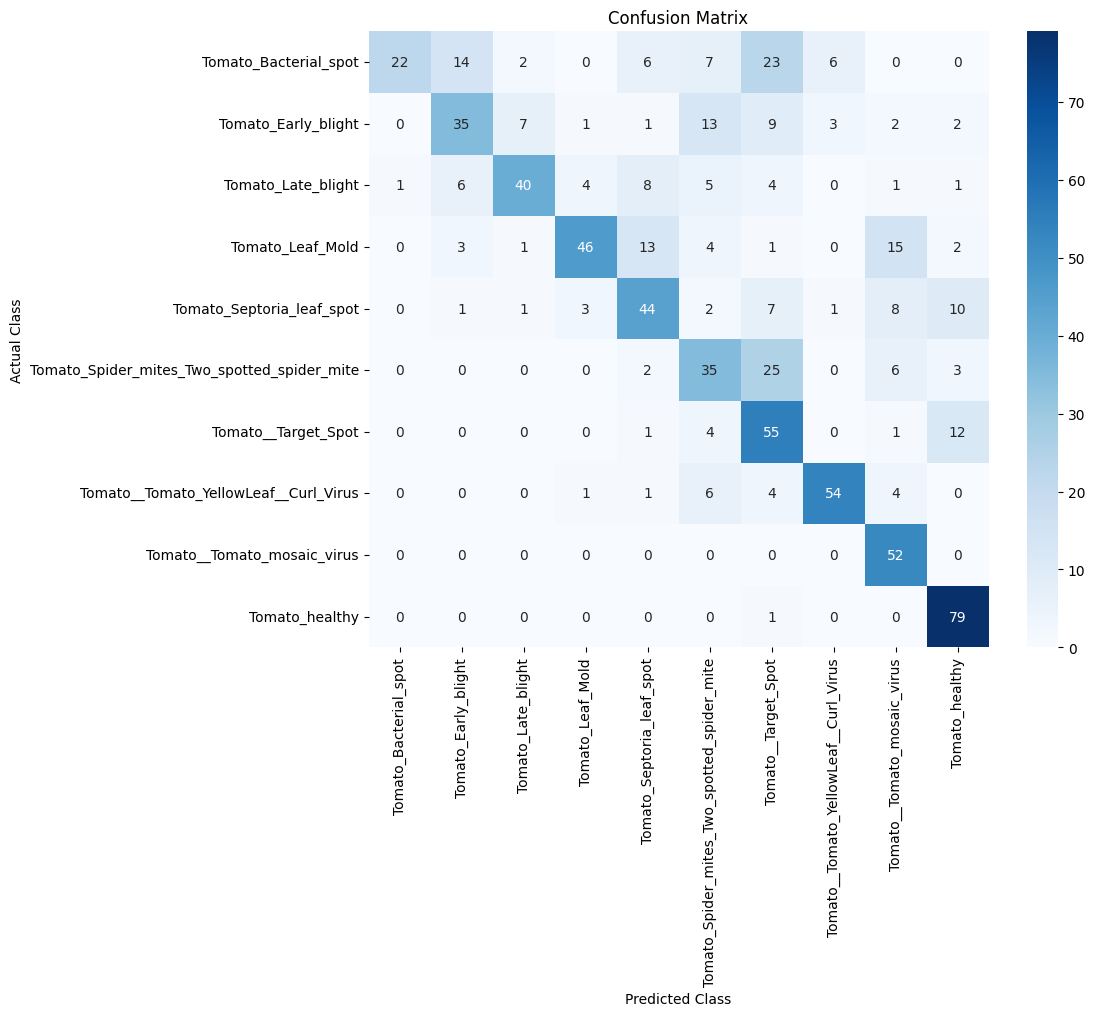

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=tomato_classes,
    yticklabels=tomato_classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

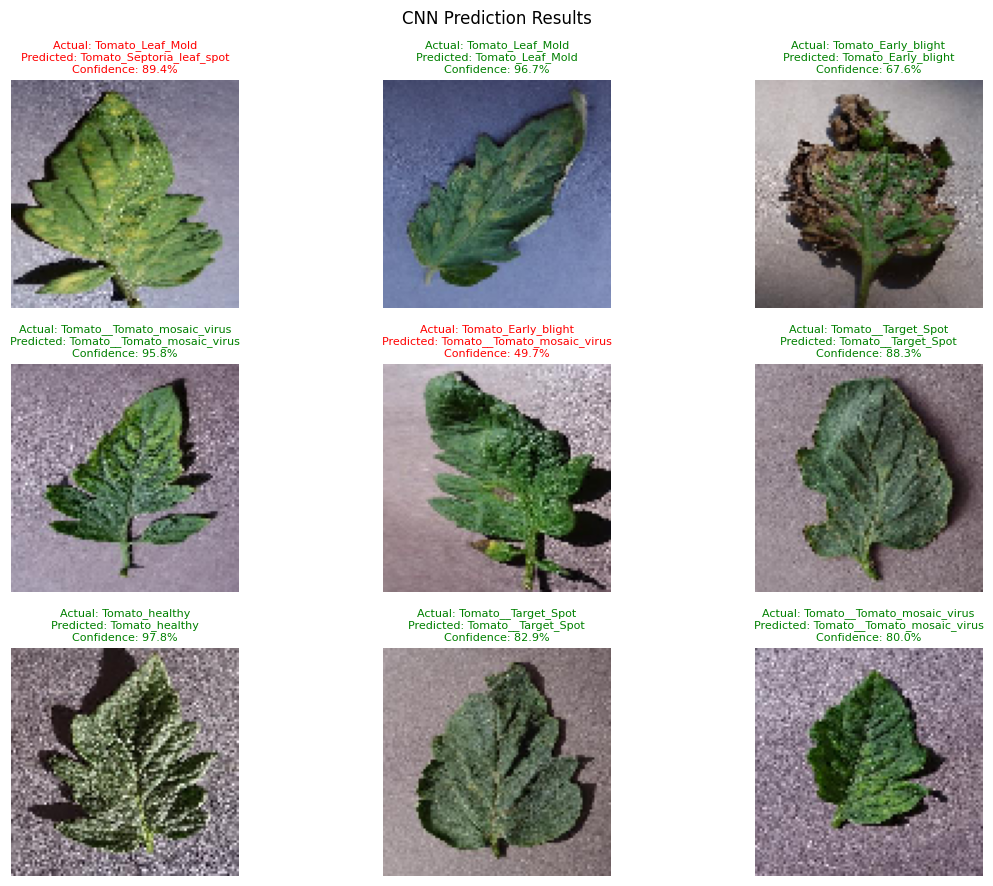

In [ ]:
plt.figure(figsize=(12, 9))

for images, labels in test_ds.take(1):

    predictions = model.predict(
        images,
        verbose=0
    )

    for i in range(
        min(9, len(images))
    ):

        predicted = np.argmax(
            predictions[i]
        )

        confidence = (
            np.max(predictions[i]) * 100
        )

        actual_name = tomato_classes[
            labels[i].numpy()
        ]

        predicted_name = tomato_classes[
            predicted
        ]

        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])

        color = (
            "green"
            if labels[i].numpy() == predicted
            else "red"
        )

        plt.title(
            f"Actual: {actual_name}\n"
            f"Predicted: {predicted_name}\n"
            f"Confidence: {confidence:.1f}%",
            color=color,
            fontsize=8
        )
        plt.axis("off")

plt.suptitle("CNN Prediction Results")
plt.tight_layout()
plt.show()

In [ ]:
model.save(
    "tomato_disease_cnn.keras"
)

print("\nModel saved successfully.")


Model saved successfully.
